In [78]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import matplotlib as plt
import numpy as np

In [79]:
telecom_data = pd.read_csv("/Users/mahdidarwish/Desktop/Telco_Customer_Churn/data/Telco-Customer-Churn.csv")
telecom_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [80]:
telecom_data['TotalCharges'] = pd.to_numeric(telecom_data['TotalCharges'], errors='coerce')


In [81]:
telecom_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [82]:
telecom_data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [83]:
telecom_data.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)

SeniorCitizen  Churn
0              No       0.763938
               Yes      0.236062
1              No       0.583187
               Yes      0.416813
Name: proportion, dtype: float64

In [84]:
telecom_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [85]:
X = telecom_data.drop(['Churn','customerID'],axis=1)
y = telecom_data['Churn'].map({'Yes': 1, 'No': 0})


In [86]:
X_training,X_testing,y_training,y_testing = train_test_split(X,y)

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


numeric_features = X_training.select_dtypes(exclude='object').columns.tolist()
categorical_features = X_training.select_dtypes(include='object').columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_pipline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer( 
    transformers=[
        ('num',numeric_pipeline,numeric_features),
        ('cat',categorical_pipline,categorical_features),
    ]
)

/var/folders/5_/l474g0n51qg78g5k727z4cq40000gn/T/ipykernel_91677/1194536875.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_training.select_dtypes(include='object').columns.tolist()


In [88]:
from sklearn.ensemble import RandomForestClassifier


full_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier())
])

In [89]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    Q1 = telecom_data[col].quantile(0.25)
    Q3 = telecom_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = telecom_data[(telecom_data[col] < lower) | (telecom_data[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (range: {lower:.1f} to {upper:.1f})")

tenure: 0 outliers (range: -60.0 to 124.0)
MonthlyCharges: 0 outliers (range: -46.0 to 171.4)
TotalCharges: 0 outliers (range: -4688.5 to 8884.7)


In [90]:
X_training.shape,X_testing.shape,y_training.shape,y_testing.shape

((5282, 19), (1761, 19), (5282,), (1761,))

In [91]:

full_pipeline.fit(X_training,y_training)
y_predc = full_pipeline.predict(X_testing)

In [92]:
full_pipeline.score(X_training,y_training)


0.9981067777357062

In [93]:
full_pipeline.score(X_testing,y_testing)

0.7921635434412265

In [94]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models_and_grids = {
    'RandomForest': (RandomForestClassifier(random_state=42),
        {'model__max_depth': [4, 6, 8, None], 'model__min_samples_leaf': [1, 5, 10], 'model__class_weight': ['balanced']}),
    'LogisticRegression': (LogisticRegression(max_iter=1000),
        {'model__C': [0.01, 0.1, 1, 10], 'model__class_weight': ['balanced']}),
    'SVC': (SVC(),
        {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf', 'linear'], 'model__class_weight': ['balanced']}),
    'KNN': (KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7, 9]})
}

results = {}
for name, (model, grid) in models_and_grids.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    search = RandomizedSearchCV(pipe, grid, n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1)
    search.fit(X_training, y_training)
    y_pred = search.predict(X_testing)
    results[name] = {'best_params': search.best_params_, 'cv_f1': search.best_score_, 'test_f1': f1_score(y_testing, y_pred)}
    print(f"{name}: CV F1={search.best_score_:.3f}, Test F1={f1_score(y_testing, y_pred):.3f}")

RandomForest: CV F1=0.637, Test F1=0.631


/Users/mahdidarwish/Desktop/Telco_Customer_Churn/venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LogisticRegression: CV F1=0.630, Test F1=0.627


/Users/mahdidarwish/Desktop/Telco_Customer_Churn/venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SVC: CV F1=0.624, Test F1=0.623


/Users/mahdidarwish/Desktop/Telco_Customer_Churn/venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KNN: CV F1=0.564, Test F1=0.532


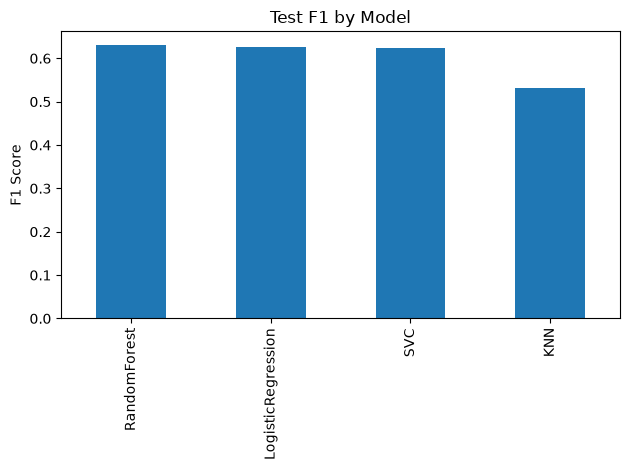

In [95]:
import matplotlib.pyplot as plt

pd.Series({name: results[name]['test_f1'] for name in results}).plot(kind='bar', title='Test F1 by Model')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.savefig('F1_Evaluation_matrix.png')
plt.show()

In [96]:
from sklearn.metrics import confusion_matrix

In [97]:
confusion_matrix(y_testing,y_predc)

array([[1166,  127],
       [ 239,  229]])

In [98]:
best_pipe = Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=5000))])
search = RandomizedSearchCV(
    best_pipe,
    {'model__C': [0.01, 0.1, 1, 10], 'model__class_weight': ['balanced']},
    n_iter=6, cv=5, scoring='f1', random_state=42
)
search.fit(X_training, y_training)
best_model = search.best_estimator_

/Users/mahdidarwish/Desktop/Telco_Customer_Churn/venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=6. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


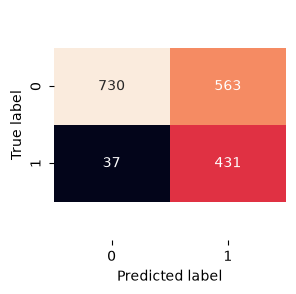

In [99]:
import seaborn as sns
def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     fmt='d',
                     cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
y_proba = best_model.predict_proba(X_testing)[:, 1]
threshold = 0.3
y_pred_thresh = (y_proba >= threshold).astype(int)

plot_conf_mat(y_testing, y_pred_thresh)


In [100]:
print("Train score:", best_model.score(X_training, y_training))
print("Test score:", best_model.score(X_testing, y_testing))

Train score: 0.751230594471791
Test score: 0.7501419647927314


In [101]:
from joblib import dump,load
dump(full_pipeline,"telco_churn_pipeline.joblib")
load("telco_churn_pipeline.joblib")
loaded_model =load("telco_churn_pipeline.joblib")

In [102]:
import pandas as pd

sample = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [12],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["Yes"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.2],
    "TotalCharges": [1022.4]
})

prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)

print(prediction)
print(probability)

[1]
[[0.38 0.62]]
